In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from datasets import load_dataset
from diffusers import DDIMScheduler, DDPMPipeline
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

import os
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Torch Version:", torch.__version__)
print("CUDA Availablility:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch Version: 2.5.1+cu121
CUDA Availablility: True
GPU Name: NVIDIA RTX 2000 Ada Generation Laptop GPU
Using device: cuda


In [3]:
image_pipe = DDPMPipeline.from_pretrained(
    "google/ddpm-cifar10-32", 
    use_safetensors=False
).to(device)

scheduler = DDIMScheduler.from_pretrained("google/ddpm-cifar10-32")
scheduler.set_timesteps(num_inference_steps=40)

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  8.39it/s]


0it [00:00, ?it/s]

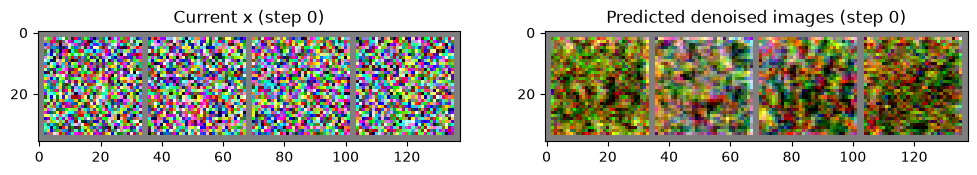

5it [00:01,  6.09it/s]

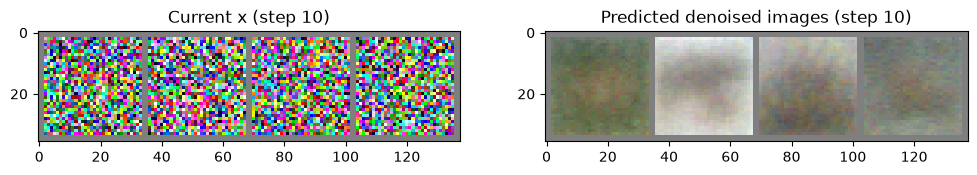

16it [00:01, 17.07it/s]

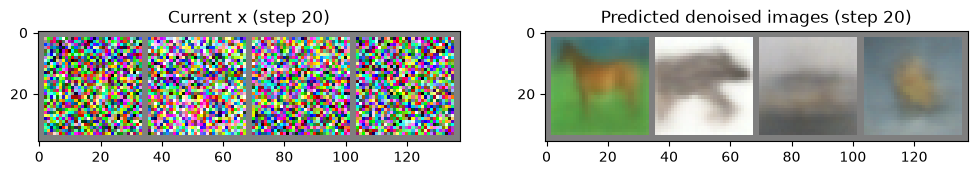

27it [00:02, 19.49it/s]

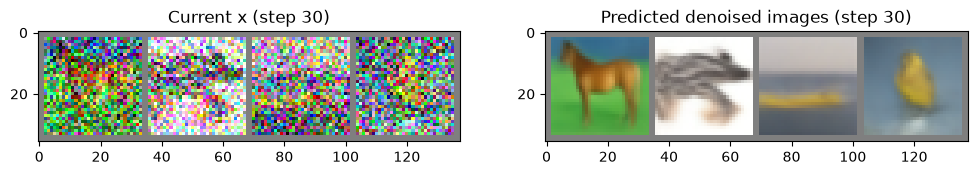

36it [00:02, 23.93it/s]

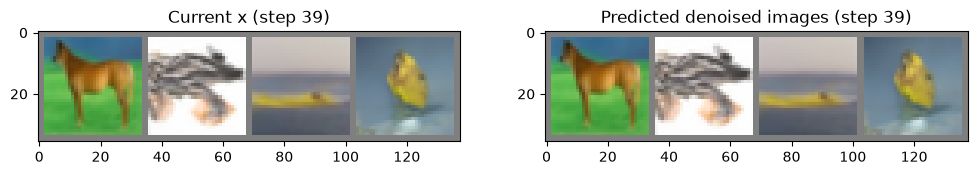

40it [00:02, 15.73it/s]


In [4]:
# The random starting point
x = torch.randn(4, 3, 32, 32).to(device)  # Batch of 4, 3-channel 256 x 256 px images

# Loop through the sampling timesteps
for i, t in tqdm(enumerate(scheduler.timesteps)):

    # Prepare model input
    model_input = scheduler.scale_model_input(x, t)

    # Get the prediction
    with torch.no_grad():
        noise_pred = image_pipe.unet(model_input, t)["sample"]

    # Calculate what the updated sample should look like with the scheduler
    scheduler_output = scheduler.step(noise_pred, t, x)

    # Update x
    x = scheduler_output.prev_sample

    # Occasionally display both x and the predicted denoised images
    if i % 10 == 0 or i == len(scheduler.timesteps) - 1:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        grid = torchvision.utils.make_grid(x, nrow=4).permute(1, 2, 0)
        axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[0].set_title(f"Current x (step {i})")

        pred_x0 = (
            scheduler_output.pred_original_sample
        )
        grid = torchvision.utils.make_grid(pred_x0, nrow=4).permute(1, 2, 0)
        axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[1].set_title(f"Predicted denoised images (step {i})")
        
        plt.show()

In [ ]:
image_pipe.scheduler = scheduler
images = image_pipe(num_inference_steps=40).images
img = images[0]

fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(img)
plt.show()

Dataset({
    features: ['id', 'image'],
    num_rows: 1498
})


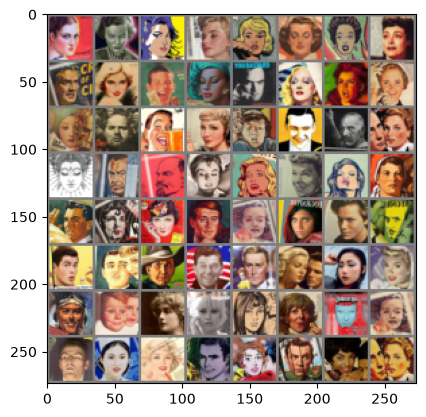

In [14]:
# Load and prepare a new dataset
dataset_name = "Norod78/Vintage-Faces-FFHQAligned"
dataset = load_dataset(dataset_name, split="train")
image_size = 32
batch_size = 64
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset=dataset, 
    batch_size=batch_size, 
    shuffle=True
)

print(dataset)
batch = next(iter(train_dataloader))
grid = torchvision.utils.make_grid(batch["images"], nrow=8)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5)

In [88]:
import json
import torch
import torch.nn.functional as F

class TrainingLogger:
    def __init__(self, save_path="fine_tuning_logs.jsonl", log_every_n_steps=10):
        self.save_path = save_path
        self.log_every_n_steps = log_every_n_steps

        # Reset/initialize the JSONL file
        with open(self.save_path, "w", encoding="utf-8") as f:
            pass

    def log(self, step, loss, lr, model=None):
        if step % self.log_every_n_steps != 0:
            return

        log_entry = {
            "step": step,
            "loss": loss,
            "learning_rate": lr
        }

        # Calculate gradient norm if model is provided
        if model is not None:
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2
            log_entry["grad_norm"] = total_norm ** 0.5

        # GPU memory metrics
        if torch.cuda.is_available():
            log_entry["gpu_alloc"] = torch.cuda.memory_allocated() / (1024**3)
            log_entry["gpu_reserved"] = torch.cuda.memory_reserved() / (1024**3)

        # Append to jsonl
        with open(self.save_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(log_entry) + "\n")
            f.flush()

In [ ]:
import time
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import get_scheduler

# Training Parameters
num_epochs = 64
lr = 1e-4
grad_accumulation_steps = 2
optimizer = torch.optim.AdamW(image_pipe.unet.parameters(), lr=lr)
losses = []

num_training_steps = num_epochs * len(train_dataloader) // grad_accumulation_steps
num_warmup_steps = int(0.1 * num_training_steps)

lr_scheduler = get_scheduler(
    name="cosine",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# Initialize Your Logger
logger = TrainingLogger(save_path="fine_tuning_logs.jsonl", log_every_n_steps=10)
global_step = 0

print("====== Start of the training loop ======")
image_pipe.unet.train()

# Training Loop
for epoch in range(num_epochs):
    start_time = time.time()

    for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch}")):
        clean_images = batch["images"].to(device)
        noise = torch.randn_like(clean_images)
        batch_size = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0,
            image_pipe.scheduler.num_train_timesteps,
            (batch_size,),
            device=clean_images.device
        ).long()

        # Forward diffusion process (add noise)
        noisy_images = image_pipe.scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction for the noise
        noise_pred = image_pipe.unet(noisy_images, timesteps, return_dict=False)[0]

        # Compute loss and scale it for gradient accumulation
        loss = F.mse_loss(noise_pred, noise)
        loss_scaled = loss / grad_accumulation_steps
        loss_scaled.backward()

        # Store for later plotting
        losses.append(loss.item())

        # Log metrics *while* gradients are fully populated (before optimizer step/zero_grad)
        current_lr = lr_scheduler.get_last_lr()[0]
        logger.log(
            step=global_step,
            loss=loss.item(),
            lr=current_lr,
            model=image_pipe.unet
        )

        # Gradient accumulation step
        if (step + 1) % grad_accumulation_steps == 0 or (step + 1) == len(train_dataloader):
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        global_step += 1

    end_time = time.time()
    total_time = end_time - start_time
    hours = int(total_time // 3600)
    minutes = int((total_time % 3600) // 60)
    seconds = total_time % 60
    
    epoch_loss = sum(losses[-len(train_dataloader):]) / len(train_dataloader)
    print(f">>> Epoch {epoch} average loss: {epoch_loss:.4f} | training time: {hours}h {minutes}m {seconds:.2f}s")

print("=========== Training is done! ===========")

====== Start of the training loop ======


Epoch 0: 100%|██████████| 24/24 [00:24<00:00,  1.02s/it]


>>> Epoch 0 average loss: 0.0350 | training time: 0h 0m 24.47s


Epoch 1: 100%|██████████| 24/24 [00:23<00:00,  1.01it/s]


>>> Epoch 1 average loss: 0.0319 | training time: 0h 0m 23.71s


...

>>> Epoch 61 average loss: 0.0321 | training time: 0h 0m 29.21s


Epoch 62: 100%|██████████| 24/24 [00:23<00:00,  1.02it/s]


>>> Epoch 62 average loss: 0.0347 | training time: 0h 0m 23.58s


Epoch 63: 100%|██████████| 24/24 [00:37<00:00,  1.54s/it]

>>> Epoch 63 average loss: 0.0308 | training time: 0h 0m 37.02s
=========== Training is done! ===========


In [90]:
# Save Fine-tuning Model Weights
print("Saving fine-tuning model weights ...")
torch.save(image_pipe.unet.state_dict(), "vintage-faces_fine-tuning_weights.pth")
print("Vintage-faces fine-tuning weights are saved!")

Saving fine-tuning model weights ...
Vintage-faces fine-tuning weights are saved!


In [91]:
# Plot function
import matplotlib.pyplot as plt
import json

def load_logs(path="train_logs.jsonl"):
    logs = []
    with open(path, "r") as f:
        for line in f:
            logs.append(json.loads(line))
            
    return logs

def prepare(logs):
    steps = [x["step"] for x in logs]
    loss = [x["loss"] for x in logs]
    lr = [x["learning_rate"] for x in logs]
    grad = [x["grad_norm"] for x in logs]
    gpu_a = [x.get("gpu_alloc") for x in logs]
    gpu_r = [x.get("gpu_reserved") for x in logs]

    return steps, loss, lr, grad, gpu_a, gpu_r

def plot_training_from_file(path="train_logs.jsonl"):
    logs = load_logs(path)
    steps, loss, lr, grad, gpu_a, gpu_r = prepare(logs)

    fig, axes = plt.subplots(6, 1, figsize=(8, 12), sharex=True)

    axes[0].plot(steps, loss, color="red")
    axes[0].set_title("Training Loss")

    axes[1].plot(steps, np.log(loss), color="tomato")
    axes[1].set_title("Training Loss in Log Scale")

    axes[2].plot(steps, lr, color="blue")
    axes[2].set_title("Learning Rate")

    axes[3].plot(steps, grad, color="green")
    axes[3].set_title("Gradient Norm")

    axes[4].plot(steps, gpu_a, color="purple")
    axes[4].set_title("GPU Allocated Memory")

    axes[5].plot(steps, gpu_r, color="orange")
    axes[5].set_title("GPU Reserved Memory")

    for ax in axes:
        ax.set_facecolor("#f5f5f5") 
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="darkgray", alpha=0.7)

    fig.suptitle("Vintage-Faces Fine-Tuning Summary", fontsize=14)
    plt.tight_layout()
    plt.savefig("vintage-faces_fine-tuning_summary.png", dpi=300)
    print("Plot successfully saved as 'vintage-faces_fine-tuning_summary.png'")

Plot successfully saved as 'vintage-faces_fine-tuning_summary.png'


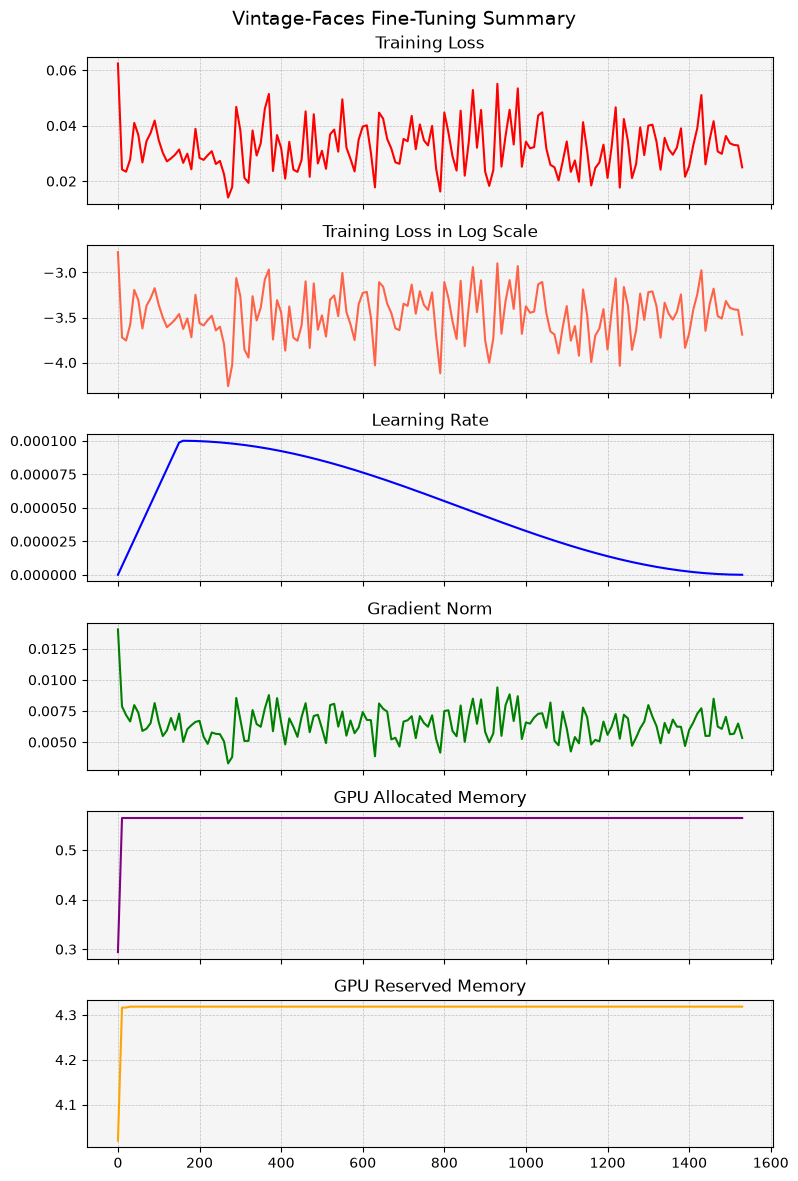

In [92]:
# Plot training loss, learning rate, gradient norm, GPU allocated memory, GPU reserved memory 
plot_training_from_file("fine_tuning_logs.jsonl")

In [15]:
# Load Fine-tuning Model Weights
model = image_pipe.unet
model.load_state_dict(torch.load('vintage-faces_fine-tuning_weights.pth', weights_only=True))
model.eval()

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

64it [00:07,  8.03it/s]


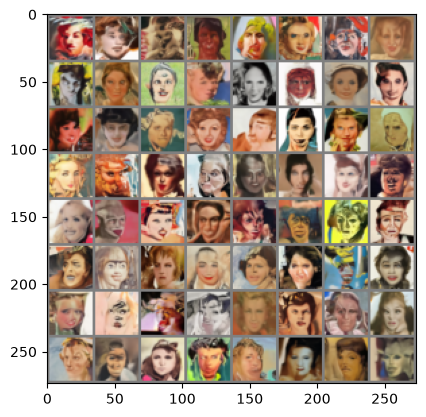

In [ ]:
# Generate some images
x = torch.randn(64, 3, 32, 32).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):
    model_input = scheduler.scale_model_input(x, t)     # format the current x_t correctly for the U-Net
    """
        scheduler.scale_model_input(x, t) prepares the current noisy sample x_t 
        in the specific numerical scale expected by the U-Net at timestep t.
    """
    with torch.no_grad():
        noise_pred = model(model_input, t)["sample"]    # predict the noise
    x = scheduler.step(noise_pred, t, x).prev_sample    # given the predicted noise, calculate the next sample x_t-1
    
grid = torchvision.utils.make_grid(x, nrow=8)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5)